<a href="https://colab.research.google.com/github/gaurizendekar/Data_Science_labs/blob/main/Exp6_Deep_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment 6: Deep NLP using TensorFlow and Keras

Aim:To implement Deep Natural Language Processing (NLP) using TensorFlow and Keras for text classification.

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Shape : (25000, 200)
Testing Shape : (25000, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 171s 537ms/step - accuracy: 0.7707 - loss: 0.4764 - val_accuracy: 0.8728 - val_loss: 0.3127
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 202s 539ms/step - accuracy: 0.9000 - loss: 0.2562 - val_accuracy: 0.8802 - val_loss: 0.2967
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 168s 534ms/step - accuracy: 0.9147 - loss: 0.2176 - val_accuracy: 0.8572 - val_loss: 0.3540
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 202s 535ms/step - accuracy: 0.9325 - loss: 0.1761 - val_accuracy: 0.8546 - val_loss: 0.3746
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 159s 509ms/step - accuracy: 0.9610 - loss: 0.1118 - val_accuracy: 0.8566 - val_loss: 0.4521
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.8536 - loss: 0.4674

Test Accuracy : 0.8536400198936462


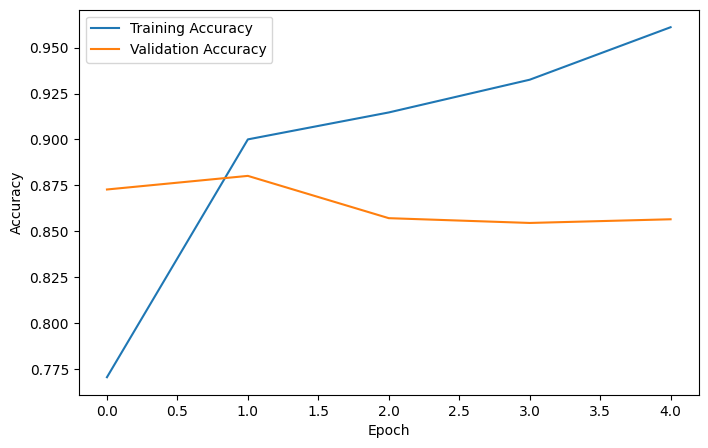

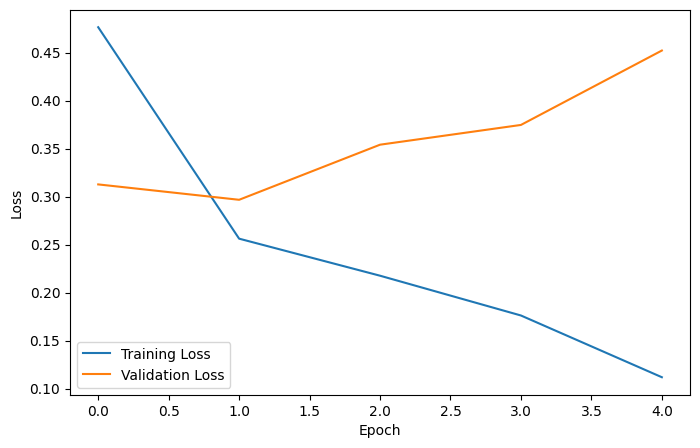

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Dense, LSTM, Bidirectional, Dropout
from tensorflow.keras import callbacks
import matplotlib.pyplot as plt

# Load IMDB Dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding Sequences
max_length = 200
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# Build an Enhanced Deep NLP Model
model = Sequential()

# Explicit Input Layer (Resolves Keras deprecation warnings)
model.add(Input(shape=(max_length,)))

# Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=128))

# Bidirectional LSTM Layer (Processes sequence in both forward and backward directions)
model.add(Bidirectional(LSTM(64, return_sequences=False)))

# Dropout Layer for Regularization
model.add(Dropout(0.5))

# Fully Connected Dense Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks (Early Stopping to prevent overfitting)
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=2, # Stops if validation loss doesn't improve for 2 epochs
    restore_best_weights=True
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10, # Increased epochs; EarlyStopping will halt it at the optimal point
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping]
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy : {test_accuracy:.4f}")
print(f"Test Loss : {test_loss:.4f}")

# Plot Accuracy and Loss Graphs (Side-by-Side View)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].legend()
ax[0].grid(True)

# Plot Loss
ax[1].plot(history.history['loss'], label='Training Loss', color='blue')
ax[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].set_title('Model Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Conclusion: Successfully implemented Deep NLP using Embedding and LSTM layers for sentiment classification on the IMDB movie review dataset.